# Parte 3 · Arquitecturas CNN modernas

**Lo que pide el enunciado (§7) y dónde está:**

| Pide | Dónde |
|---|---|
| Al menos dos arquitecturas modernas | ResNet-18 (E03), ResNet-50 (E04), EfficientNet-B0 (E05) |
| Idea principal, problema que resuelve, componentes, complejidad, por qué se eligió | §1 |
| Condiciones experimentales equivalentes | §2: solo cambia `modelo` |
| Rendimiento en validación, velocidad de convergencia, parámetros, coste, comportamiento de la pérdida | §3 |

Implementación: `modelos.crear_modelo` usa las arquitecturas de torchvision y sustituye la última capa por
una de 10 000 salidas.

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Las arquitecturas

| | **ResNet-18 / ResNet-50** (He et al., 2016) | **EfficientNet-B0** (Tan & Le, 2019) |
|---|---|---|
| Idea principal | Bloques residuales: cada bloque aprende una corrección $F(x)$ y devuelve $x + F(x)$ | Escalado compuesto: profundidad, anchura y resolución crecen juntas a partir de una red base hallada por búsqueda automática (NAS) |
| Problema que resuelve | Al apilar muchas capas la red entrenaba *peor* (degradación, gradiente que se desvanece). El atajo identidad deja pasar señal y gradiente | Eficiencia: la mejor accuracy por FLOP y por parámetro |
| Componentes | Convolución 7×7 inicial, 4 etapas de bloques (R18: bloque básico 3×3-3×3; R50: *bottleneck* 1×1-3×3-1×1), BatchNorm, ReLU, *global average pooling* | Bloques MBConv (*inverted residual* con convolución *depthwise*), *Squeeze-and-Excitation*, activación SiLU, dropout en la cabeza |
| Complejidad (a 224 px, ImageNet) | R18: 11,7 M params, 1,8 GMACs · R50: 25,6 M params, 4,1 GMACs | 5,3 M params, 0,39 GMACs |
| Por qué aquí | Referencia estándar, robusta al entrenar desde cero con SGD. R50 es el backbone clásico de iNaturalist y el que se usa en transfer (Parte 6) | 10 veces menos cómputo: a gran escala, ¿la eficiencia teórica se traduce en velocidad real y en accuracy? |

**Ojo con la cabeza de 10 000 clases:** 512×10⁴ = 5,1 M parámetros en R18, 20,5 M en R50 (casi la mitad
del modelo) y 12,8 M en B0. La tabla de §3 da los parámetros y los GFLOPs reales a 128 px.

## 2. Definición: misma receta, solo cambia la arquitectura

In [2]:
definiciones([("E03", "(defecto)"), ("E04", "E03"), ("E05", "E03")])

,referencia,descripción,estado,cambios
ID,,,,
E03,(defecto),ResNet-18 desde cero (receta base),terminado,(referencia)
E04,E03,ResNet-50 desde cero,terminado,modelo: resnet18 → resnet50
E05,E03,EfficientNet-B0 desde cero,terminado,modelo: resnet18 → efficientnet_b0


## 3. Resultados

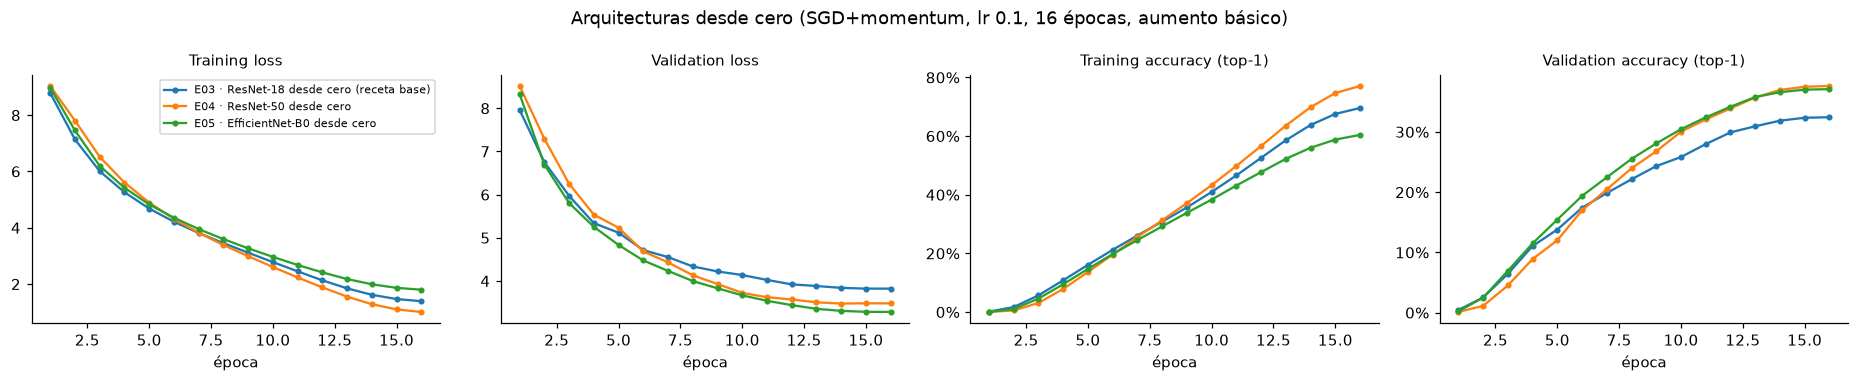

,descripción,top1,top5,f1_macro,f1_weighted,train_top1,brecha_top1,brecha_loss,mejor_ep,épocas,params_M,entrenables_M,GFLOPs,img_s,min_total,gpu,época 90%
ID,,,,,,,,,,,,,,,,,
E03,ResNet-18 desde cero (receta base),32.4%,54.5%,31.8%,31.8%,69.6%,37.2%,2.43,16,16,16.3,16.3,1.19,4750,27,RTX A6000,12
E04,ResNet-50 desde cero,37.6%,60.4%,37.1%,37.1%,77.1%,39.5%,2.47,16,16,44.0,44.0,2.71,1763,75,RTX A6000,12
E05,EfficientNet-B0 desde cero,37.0%,60.0%,36.3%,36.3%,60.4%,23.4%,1.48,16,16,16.8,16.8,0.28,3645,37,RTX A6000,12


In [3]:
curvas(R, ["E03", "E04", "E05"], "Arquitecturas desde cero (SGD+momentum, lr 0.1, 16 épocas, aumento básico)")
t = tabla(R, ["E03", "E04", "E05"])
if len(t):
    t["época 90%"] = [epoca_para(R, i) for i in t.index]
t.style.format(FMT) if len(t) else None

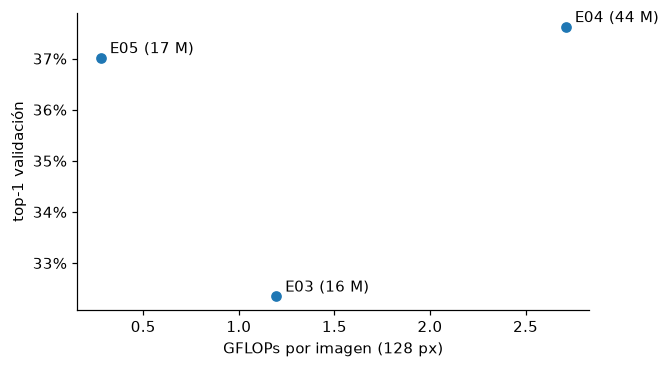

In [4]:
if len(t):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.scatter(t.GFLOPs, t.top1)
    for i, r in t.iterrows():
        ax.annotate(f"{i} ({r.params_M:.0f} M)", (r.GFLOPs, r.top1), textcoords="offset points", xytext=(6, 3))
    ax.set_xlabel("GFLOPs por imagen (128 px)"); ax.set_ylabel("top-1 validación")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}")); plt.show()

**Lectura de los resultados** (las tres corrieron en la misma RTX A6000, así que los tiempos son comparables):

| | Top-1 | Top-5 | Macro-F1 | Parámetros | GFLOPs (128 px) | img/s | Tiempo | Train top-1 |
|---|---|---|---|---|---|---|---|---|
| ResNet-18 (E03) | 32,4 % | 54,5 % | 31,8 % | 16,3 M | 1,19 | 4 750 | 27 min | 69,6 % |
| ResNet-50 (E04) | **37,6 %** | **60,4 %** | **37,1 %** | 44,0 M | 2,71 | 1 760 | 75 min | 77,1 % |
| EfficientNet-B0 (E05) | 37,0 % | 60,0 % | 36,3 % | 16,8 M | **0,28** | 3 650 | 37 min | 60,4 % |

* **Rendimiento:** ResNet-50 y EfficientNet-B0 quedan prácticamente empatadas (37,6 % frente a 37,0 %,
  una diferencia dentro del ruido de una sola semilla), ambas unos 5 pp por encima de ResNet-18.
* **Complejidad frente a coste real:** EfficientNet-B0 logra lo mismo que ResNet-50 con **~10 veces menos
  FLOPs** y 2,6 veces menos parámetros. Pero en la GPU no es 10 veces más rápida, solo ~2 veces (3 650
  frente a 1 760 img/s), y es **más lenta que ResNet-18**, que hace 4 veces más FLOPs. Las convoluciones
  *depthwise* de los bloques MBConv hacen muy pocas operaciones por byte leído de memoria: la GPU pasa más
  tiempo moviendo datos que calculando. **Los FLOPs no predicen el tiempo real en GPU.**
* **Generalización:** EfficientNet-B0 sobreajusta menos (train 60 % frente a 77 % de ResNet-50, con el
  mismo val). Tiene menos capacidad y su cabeza trae dropout 0,2 de serie.
* **Convergencia:** las tres llegan al 90 % de su mejor top-1 en la época 12 y siguen mejorando en la 16.
  Con más épocas todas mejorarían: es una limitación del presupuesto.
* **Estabilidad:** EfficientNet-B0 tuvo picos de norma del gradiente (~15) en las primeras épocas,
  absorbidos por el recorte a norma 5; ResNet-50 tuvo un pico aislado de ~78. Las curvas de pérdida no se
  resienten en ningún caso.
* **CNN seleccionada para las Partes 4 y 5:** **ResNet-18**. Rinde 5 pp menos, pero es la más rápida en
  tiempo real y permitió hacer 14 corridas controladas de optimización y regularización. Las conclusiones
  de esas partes son *comparativas* (A frente a B con la misma red), y para eso la red barata basta.